# AR — optimization curves on CTR23 regression (permuted labels)

Regression twin of `optimization_analysis.ipynb`. The AR script (`A` ported to
**OpenML-CTR23**, L2 loss / MSE fitness) writes **one run per dataset**, all with
**permuted training targets** — the overfitting probe. So unlike the B/C notebook
there is *no* real-vs-random pairing and *no* multi-init envelope here: each
dataset has a single memorizing trajectory.

What the trace contains (per checkpoint): on the **training** set `loss` (MSE),
`mse` (= the "MSE accuracy", lower is better) and `r2`; and — for runs produced
after the trainer was extended — `test_mse`, the **held-out** MSE evaluated at the
same checkpoints. We plot the train and test MSE curves together; older runs that
only stored the scalar `final_test_mse` fall back to a horizontal line.

Targets are standardized (unit variance), so **MSE ≈ 1.0 = predicting the mean**
and **MSE → 0 = memorizing the permuted targets**.

In [1]:
import pickle
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
# AR pkls are staged here (same place summarize_results.py reads).
RESULTS = ROOT / "results" / "summarizing"
assert RESULTS.is_dir(), RESULTS

# AR filename: fold{F}_layers{L}_hidden{H}_epc{E}_{dataset}.pkl  (no seed, single run)
FNAME = re.compile(r"^fold\d+_layers\d+_hidden\d+_epc\d+_(?P<dataset>.+)\.pkl$")

def discover(results: Path) -> dict[str, Path]:
    'Map dataset -> pkl path for every AR run file (one run per dataset).'
    found = {}
    for p in sorted(results.glob("*.pkl")):
        m = FNAME.match(p.name)
        if m:
            found[m.group("dataset")] = p
    return found

runs = discover(RESULTS)
print(f"{len(runs)} AR regression runs:")
print(", ".join(sorted(runs)))

3 AR regression runs:
cars, cpu_activity, energy_efficiency


## 1. Load curves and final MSE per dataset

Each run is loaded into its epoch grid plus the per-checkpoint training MSE / loss
/ R², and the scalar final train/test MSE. We keep only regression payloads
(`task == "regression"`) so a stray classification pkl can't sneak in.

In [2]:
def load_run(path: Path) -> dict | None:
    d = pickle.load(open(path, "rb"))
    if d.get("task") != "regression":
        return None
    tr = d["trace"]
    return {
        "epoch": np.asarray(tr["epoch_idx"], int),
        "mse": np.asarray(tr["mse"], float),
        "loss": np.asarray(tr["loss"], float),
        "r2": np.asarray(tr["r2"], float),
        # Per-checkpoint held-out MSE (added to the trainer later); empty for
        # older runs that only kept the scalar final_test_mse.
        "test_mse": np.asarray(tr.get("test_mse", []), float),
        "final_train_mse": float(d.get("final_train_mse", np.nan)),
        "final_test_mse": float(d.get("final_test_mse", np.nan)),
        "n_train": int(d.get("n_train", -1)),
        "in_dim": int(d.get("in_dim", -1)),
    }

data = {ds: r for ds, p in sorted(runs.items()) if (r := load_run(p)) is not None}
datasets = sorted(data)
n_test_curve = sum(d["test_mse"].size > 0 for d in data.values())
print(f"loaded {len(data)} regression runs ({n_test_curve} with a per-epoch test curve)")

loaded 3 regression runs (3 with a per-epoch test curve)


## 2. Final train / test MSE and the generalization gap

Per dataset: final **train** MSE, final **test** MSE, and the gap
(`test - train`). Memorizing permuted targets should drive **train MSE → 0** while
**test MSE stays ≈ 1** (predicting the mean) — a large positive gap.

In [3]:
summary = pd.DataFrame([
    {
        "dataset": ds,
        "n_train": d["n_train"], "in_dim": d["in_dim"],
        "train_mse": d["final_train_mse"],
        "test_mse": d["final_test_mse"],
        "gen_gap": d["final_test_mse"] - d["final_train_mse"],
        "final_r2_train": d["r2"][-1],
    }
    for ds, d in data.items()
]).sort_values("gen_gap", ascending=False).reset_index(drop=True)
display(summary.round(4))

,dataset,n_train,in_dim,train_mse,test_mse,gen_gap,final_r2_train
0,cars,723,17,0.4245,2.9701,2.5456,0.5755
1,cpu_activity,7372,21,0.0532,1.9031,1.8499,0.9468
2,energy_efficiency,691,8,0.0000,1.1922,1.1922,1.0000


## 3. Training- and test-MSE curves (the optimization process)

Train MSE (red) and **test MSE** (blue) over epochs per dataset (lower = better).
When the run has a per-checkpoint test curve we plot it as a solid line; otherwise
we fall back to a dashed horizontal line at the scalar `final_test_mse`. The
diverging curves — train heading toward 0 while test stalls near 1 — are the
memorization signature.

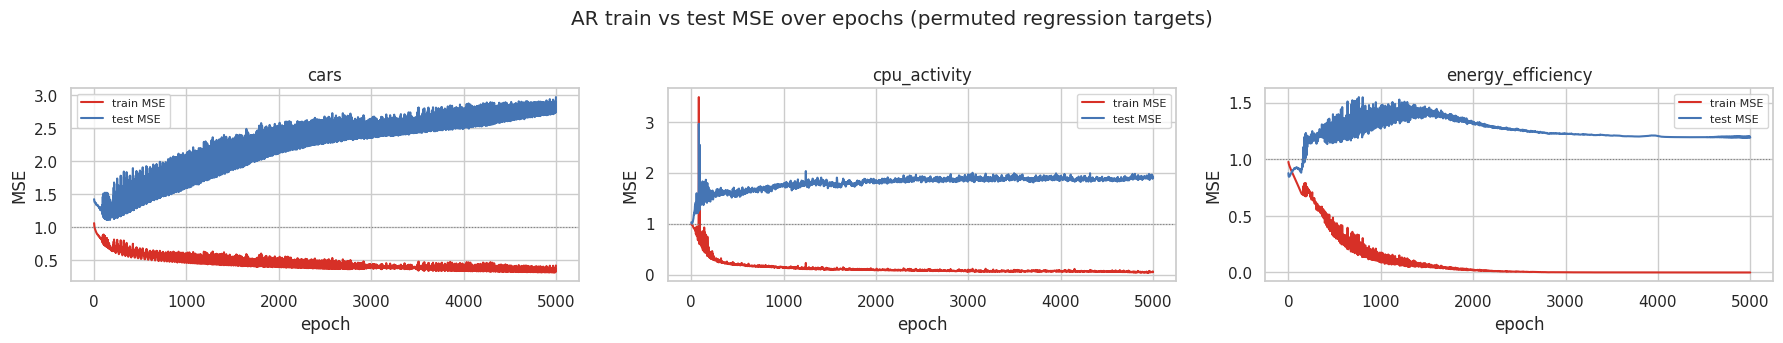

In [4]:
ncol = 3
nrow = int(np.ceil(len(datasets) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(6 * ncol, 3.4 * nrow), squeeze=False)
C_TRAIN, C_TEST = "#d73027", "#4575b4"
for ax, ds in zip(axes.ravel(), datasets):
    d = data[ds]
    ax.plot(d["epoch"], d["mse"], color=C_TRAIN, label="train MSE")
    if d["test_mse"].size > 0:
        ax.plot(d["epoch"], d["test_mse"], color=C_TEST, label="test MSE")
    elif np.isfinite(d["final_test_mse"]):
        ax.axhline(d["final_test_mse"], ls="--", color=C_TEST, lw=1.2,
                   label="final test MSE")
    ax.axhline(1.0, ls=":", color="grey", lw=0.8)  # MSE=1 -> predicting the mean
    ax.set(title=ds, xlabel="epoch", ylabel="MSE")
    ax.legend(fontsize=8)
for ax in axes.ravel()[len(datasets):]:
    ax.axis("off")
fig.suptitle("AR train vs test MSE over epochs (permuted regression targets)", y=1.005)
plt.tight_layout(); plt.show()

## 4. Training-loss curves

The L2 loss the optimizer actually minimizes (here equal to the training MSE in
standardized-target units, so this is a sanity echo of §3 on a free y-axis).

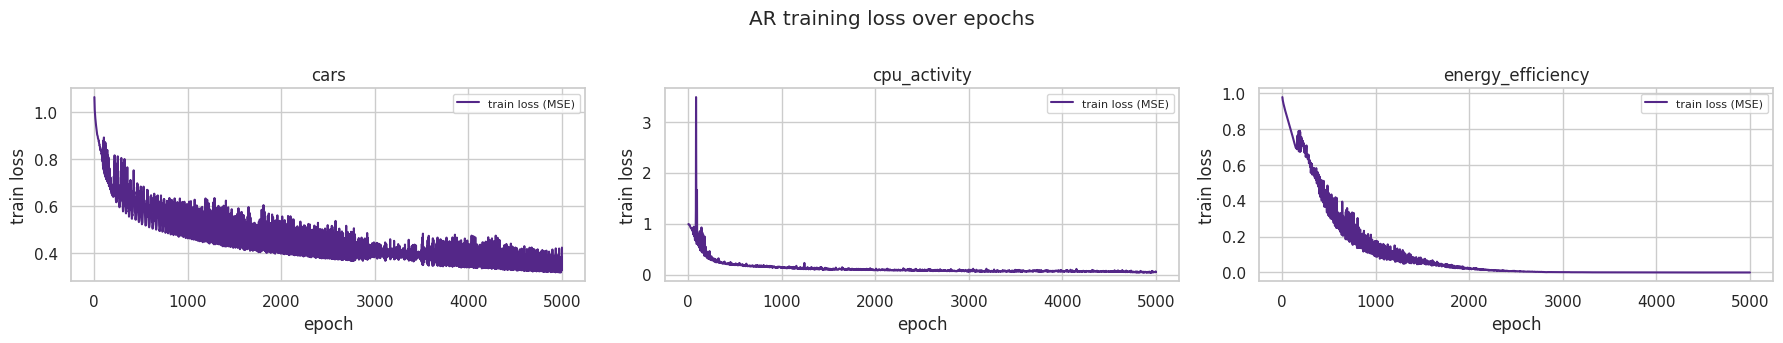

In [5]:
fig, axes = plt.subplots(nrow, ncol, figsize=(6 * ncol, 3.4 * nrow), squeeze=False)
for ax, ds in zip(axes.ravel(), datasets):
    d = data[ds]
    ax.plot(d["epoch"], d["loss"], color="#542788", label="train loss (MSE)")
    ax.set(title=ds, xlabel="epoch", ylabel="train loss")
    ax.legend(fontsize=8)
for ax in axes.ravel()[len(datasets):]:
    ax.axis("off")
fig.suptitle("AR training loss over epochs", y=1.005)
plt.tight_layout(); plt.show()

## 5. Training-R² curves

R² on the training set (1 = perfect fit). Rising toward 1 = the net is fitting the
permuted targets; on standardized targets R² ≈ 1 − train-MSE.

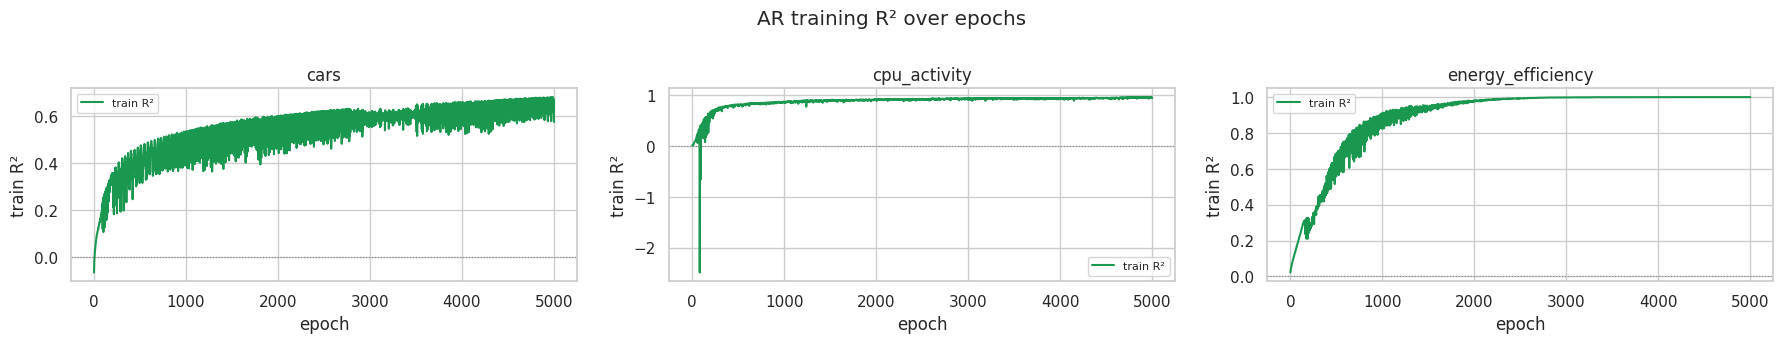

In [6]:
fig, axes = plt.subplots(nrow, ncol, figsize=(6 * ncol, 3.4 * nrow), squeeze=False)
for ax, ds in zip(axes.ravel(), datasets):
    d = data[ds]
    ax.plot(d["epoch"], d["r2"], color="#1a9850", label="train R²")
    ax.axhline(0.0, ls=":", color="grey", lw=0.8)
    ax.set(title=ds, xlabel="epoch", ylabel="train R²")
    ax.legend(fontsize=8)
for ax in axes.ravel()[len(datasets):]:
    ax.axis("off")
fig.suptitle("AR training R² over epochs", y=1.005)
plt.tight_layout(); plt.show()

## 6. Reading it

- AR uses **permuted** training targets on every dataset, so a flexible MLP should
  **drive train MSE → 0 / R² → 1** (it memorizes) while **test MSE stays ≈ 1**
  (predicting the mean): the §2 gap is the memorization signature in regression.
- This is the *A-style* single-run probe — there is no real-vs-random or multi-init
  structure here. That design returns with **BR/CR** (multi-init, real labels vs
  permuted), at which point the real-vs-random envelope plots from
  `optimization_analysis.ipynb` apply, with `acc → mse`, `f1 → r2`.
- A run whose **train MSE plateaus well above 0** is under-fitting (too few epochs /
  too small a net for that dataset), not memorizing — worth flagging per dataset.